In [19]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import sacc

from astropy.table import Table
from astropy.io import fits
from pathlib import Path
from scipy.interpolate import interp1d

import src.statistics.spline as spline
import src.statistics.corrfiles as cf

ROOT = cf.get_base_dir()

In [36]:
sc = [.3, 3]  # scale cut in Mpc/h
version = "vF"

results_dir = Path(f"{ROOT}/results/")
root = results_dir / f"splines_{sc[0]}_{sc[1]}_{version}/"
temp = (
    results_dir
    / f"distributions/{sc[0]}_{sc[1]}/nz_samples_{sc[0]}_{sc[1]}_{version}.fits"
)
output = (
    results_dir
    / f"distributions/{sc[0]}_{sc[1]}/nz_samples_{sc[0]}_{sc[1]}_{version}.sacc"
)
prefix_spl = "spl_npz_bs_bp_mag_"

splines_dict = {
    tomo: spline.BayesianBSpline.from_saved_model(f"{root}/{prefix_spl}{tomo}")
    for tomo in [1, 2, 3, 4]
}
metadata = {
    tomo: pkl.load(open(f"{root}/{prefix_spl}{tomo}_meta.pkl", "rb"))
    for tomo in [1, 2, 3, 4]
}
bounds = {"1": (0, 0.8), "2": (0.3, 1.3), "3": (0.3, 2.1), "4": (0.7, 2.1)}

PyMC model recreated from parameters
Model loaded from:
  - Trace: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/splines_0.3_3_vF/spl_npz_bs_bp_mag_1.nc
  - Metadata: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/splines_0.3_3_vF/spl_npz_bs_bp_mag_1_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/splines_0.3_3_vF/spl_npz_bs_bp_mag_2.nc
  - Metadata: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/splines_0.3_3_vF/spl_npz_bs_bp_mag_2_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/splines_0.3_3_vF/spl_npz_bs_bp_mag_3.nc
  - Metadata: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/splines_0.3_3_vF/spl_npz_bs_bp_mag_3_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded

In [37]:
tomo_samples = {}
z_eval_full = np.linspace(0, 3, 1001)
## take the midpoints of z_eval_full
z_eval_full = 0.5 * (z_eval_full[1:] + z_eval_full[:-1])
for tomo in range(1, 5):
    spl = splines_dict[tomo]

    # splines are defined from the zv values. We only evaluate within the range of the spline.
    # if one builds the splines from the "boundaries" then you get negative splines at the edges since
    # edge knots are at the zv boundaries.
    mask = (z_eval_full > spl.zv.min()) & (z_eval_full < spl.zv.max())

    z_eval = z_eval_full[mask]
    basis_eval = spl._create_evaluation_basis(z_eval)
    coeffs_samples = spl.coeffs_samples
    amplitude_samples = spl.amplitude_samples

    assert np.all(coeffs_samples >= 0), f"Warning: negative coeffs in tomo {tomo}"
    assert np.all(amplitude_samples >= 0), f"Warning: negative amplitude in tomo {tomo}"
    assert np.all(basis_eval >= 0), f"Warning: negative basis in tomo {tomo}"

    nz_samples_full = (coeffs_samples @ basis_eval.T) * amplitude_samples[:, np.newaxis]

    interp_func = interp1d(
        z_eval, nz_samples_full, axis=1, bounds_error=False, fill_value=0
    )
    nz_samples = interp_func(z_eval_full)
    complete_nz_samples = np.array(
        [nzs / np.trapezoid(nzs, z_eval_full) for nzs in nz_samples]
    )

    tomo_samples[tomo] = complete_nz_samples

Text(0, 0.5, 'n(z)')

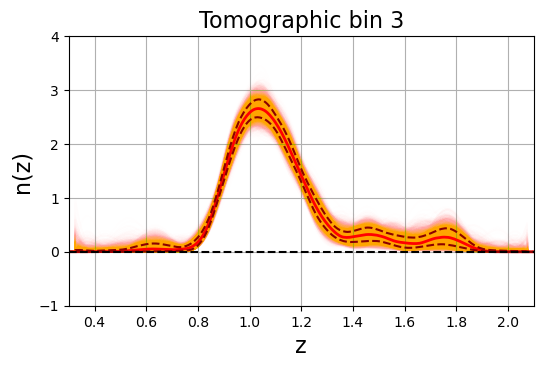

In [43]:
# let's plot an example tomographic bin
tomo = 3
complete_nz_samples = tomo_samples[tomo]
plt.figure(figsize=(6, 3.5))
plt.plot(z_eval_full, complete_nz_samples.T, color="orange", alpha=0.004)
plt.plot(z_eval_full, np.median(complete_nz_samples, axis=0), color="red", linewidth=2)
plt.plot(
    z_eval_full,
    np.percentile(complete_nz_samples, 16, axis=0),
    color="darkred",
    ls="--",
)
plt.plot(
    z_eval_full,
    np.percentile(complete_nz_samples, 84, axis=0),
    color="darkred",
    ls="--",
)
plt.title(f"Tomographic bin {tomo}", fontsize=16)
plt.axhline(0, color="k", ls="--")
plt.ylim(-1, 4)
plt.xlim(bounds[str(tomo)])
plt.grid()
plt.xlabel("z", fontsize=16)
plt.ylabel("n(z)", fontsize=16)

In [39]:
data_set = "bs_bp_mag_vF"  # name of the dataset
n_reals = tomo_samples[1].shape[0]

hdu_list = fits.HDUList()
hdu_list.append(fits.PrimaryHDU())

dz = z_eval_full[1] - z_eval_full[0]
z_low = z_eval_full - dz / 2
z_high = z_eval_full + dz / 2

for i_real in range(n_reals):
    tab = Table()

    tab["Z_LOW"] = z_low
    tab["Z_MID"] = z_eval_full
    tab["Z_HIGH"] = z_high

    for tomo in range(1, 5):
        sample_z = tomo_samples[tomo][i_real, :].copy()
        # renormalize for good measure, the samples should already be normalized
        norm = np.trapezoid(sample_z, z_eval_full)
        if norm > 0:
            sample_z = sample_z / norm

        tab[f"BIN{tomo}"] = sample_z
    extname = f"nz_{data_set}_realisation_{i_real}"
    hdu = fits.BinTableHDU(tab)
    # force lowercase extension name (to comply with what nz_multirank expects in CosmoSIS)
    hdu.header["EXTNAME"] = extname.lower()

    hdu_list.append(hdu)

hdu_list.writeto(temp, overwrite=True)

In [40]:
Table.read(temp, hdu=1)

Z_LOW,Z_MID,Z_HIGH,BIN1,BIN2,BIN3,BIN4
float64,float64,float64,float64,float64,float64,float64
-2.168404344971009e-19,0.0015,0.003,0.0,0.0,0.0,0.0
0.003,0.0045000000000000005,0.006000000000000001,0.0,0.0,0.0,0.0
0.006,0.007500000000000001,0.009000000000000001,0.0,0.0,0.0,0.0
0.009000000000000001,0.0105,0.012,0.0,0.0,0.0,0.0
0.012,0.0135,0.015,0.0,0.0,0.0,0.0
0.015000000000000001,0.0165,0.018000000000000002,0.0,0.0,0.0,0.0
0.018000000000000002,0.019500000000000003,0.021000000000000005,0.0,0.0,0.0,0.0
0.020999999999999998,0.0225,0.024,0.0,0.0,0.0,0.0
0.024,0.025500000000000002,0.027000000000000003,3.3139446419721037e-05,0.0,0.0,0.0


/global/cfs/projectdirs/desi/users/jchdj/conda/envs/pymc-env/lib/python3.13/site-packages/sacc/sacc.py:935: UserWarning: The FITS format without the 'sacc_ordering' column is deprecated. Assuming data rows are in the correct order as it was before version 1.0.
  warnings.warn(


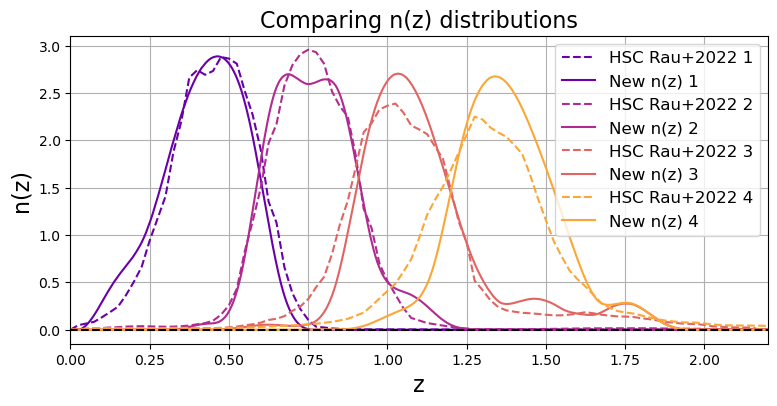

In [44]:
add_ext = False
colors = plt.get_cmap("plasma")([0.2, 0.4, 0.6, 0.8])

# Load the SACC file and update the tracers (NB : this comes from the cosmosis-standard-library.)
sacc_file = Path(
    "/global/cfs/projectdirs/desi/users/jchdj/software/cosmosis-standard-library/likelihood/hsc_cosmic_shear/hsc_y3_fourier_shear.sacc"
)
assert (
    sacc_file.exists()
), f"SACC file {sacc_file} does not exist! You can download it from the cosmosis-standard-library repository."
file = sacc.Sacc.load_fits(sacc_file)

if add_ext:
    output_file = Path(str(output).replace(".sacc", "_withsamples.sacc"))
else:
    output_file = output

plt.figure(figsize=(9, 4))
with fits.open(temp) as hdul:
    for tomo in range(1, 5):
        z_new = np.median(tomo_samples[tomo], axis=0)
        z_new /= np.trapezoid(z_new, z_eval_full)
        z_orig = file.tracers[f"wl_{tomo-1}"].z
        nz_orig = file.tracers[f"wl_{tomo-1}"].nz
        renorm = np.trapezoid(nz_orig, z_orig)
        # place distributions on the same scales
        plt.plot(
            file.tracers[f"wl_{tomo-1}"].z,
            file.tracers[f"wl_{tomo-1}"].nz / renorm,
            color=colors[tomo - 1],
            linestyle="--",
            label=f"HSC Rau+2022 {tomo}",
        )
        file.tracers[f"wl_{tomo-1}"].nz = z_new
        file.tracers[f"wl_{tomo-1}"].z = z_eval_full
        plt.plot(
            file.tracers[f"wl_{tomo-1}"].z,
            file.tracers[f"wl_{tomo-1}"].nz,
            color=colors[tomo - 1],
            label=f"New n(z) {tomo}",
        )

sacc.Sacc.save_fits(file, output_file, overwrite=True)
plt.grid()
plt.xlim(0, 2.2)
plt.axhline(0, color="k", ls="--")
plt.legend(fontsize=12)
plt.title("Comparing n(z) distributions", fontsize=16)
plt.xlabel("z", fontsize=16)
plt.ylabel("n(z)", fontsize=16)

if add_ext:
    with fits.open(output_file, mode="update") as sacc_hdul:
        with fits.open(temp) as samples_hdul:
            # Add all extensions except the primary HDU
            for ext in samples_hdul[1:]:
                sacc_hdul.append(ext.copy())

    print(f"Added {len(samples_hdul)-1} extensions to SACC file {output}")

In [42]:
with fits.open(output_file) as sacc_hdul:
    print(sacc_hdul.info())

Filename: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/distributions/0.3_3/nz_samples_0.3_3_vF.sacc
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  2  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  3  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  4  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  5  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  6  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  7  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  8  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  9  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
 10  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
 11  tracer:NZ:wl_0    1 BinTab